In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Defining loss function, MSE (observed - predicted)^2 / n
# Firstly, we have to find what we predict for each sample.

def loss(x,y,w,b):

  ss = 0

  for i in range(len(x)):

    ss += pow((y[i] - (w * x[i] + b)), 2)


  return ss / len(x)


In [3]:
# In this step, gradient descent is performed.
# We took the derivative of the loss function, then found the gradient for each parameter.
# Specified step size, and updated params.

def step(x,y,w,b, learning_rate):

  grad_w = 0
  grad_b = 0

  for i in range(len(x)):

    grad_w +=  2 * (y[i] - (w * x[i] + b)) * (-x[i])
    grad_b +=  2 * (y[i] - (w * x[i] + b)) * (-1)

  step_size_w = grad_w / len(x) * learning_rate
  step_size_b = grad_b / len(x) * learning_rate

  w -= step_size_w
  b -= step_size_b

  return w, b

In [4]:
# Function that performs linear regression with gradient descent.
# Initialized starting values for the parameters.
# Started a while loop that continues until counter reaches the max steps.
# Each iteration is a gradient descent step.

def fit(x, y, learning_rate=0.045, max_step=1000):

  w = 1
  b = 0

  n_iter = 0
  losses = []
  w_hist = []
  b_hist = []

  w_hist.append(w)
  b_hist.append(b)
  losses.append(loss(x,y,w,b))

  while(n_iter < max_step):

    w, b = step(x,y,w,b, learning_rate)

    curr_loss = loss(x,y,w,b)

    losses.append(curr_loss)
    w_hist.append(w)
    b_hist.append(b)

    n_iter += 1

  return w, b, losses, w_hist, b_hist


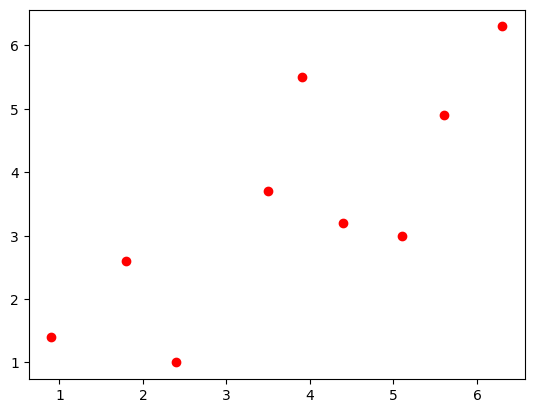

In [5]:
# Defining training set
# X = weights of the mice
# Y = sizes of the mice

y = np.array([1.4, 2.6, 1.0, 3.7, 5.5, 3.2, 3.0, 4.9, 6.3])
x = np.array([0.9, 1.8, 2.4, 3.5, 3.9, 4.4, 5.1, 5.6, 6.3])

plt.scatter(x,y, color='red')
plt.show()

In [6]:
def plot_runs(x, y, lrs, true_w, true_b, max_step=1000):
  results = {}
  fig, axes = plt.subplots(1,3, figsize = (18,5))

  for lr in lrs:
    w, b, losses, w_hist, b_hist = fit(x,y, learning_rate=lr, max_step=max_step)
    results[lr] = (w,b)
    axes[0].plot(losses, label=f"lr={lr}")
    axes[1].plot(w_hist, label=f"lr={lr}")
    axes[2].plot(b_hist, label=f"lr={lr}")
    print(f"lr: {lr}, w: {w}, b: {b}")

  axes[0].set_title('Loss')
  axes[0].set_yscale('log')
  axes[0].set_ylabel('MSE')

  axes[1].axhline(true_w, color='black', linestyle='dashed', label='true w')
  axes[1].set_title('w')

  axes[2].axhline(true_b, color='black', linestyle='dashed', label='true b')
  axes[2].set_title('b')

  for ax in axes:
      ax.set_xlabel('Iteration')
      ax.legend()

  plt.tight_layout()
  plt.show()
  return results

lr: 0.001, w: 0.8747511498925697, b: 0.14602264700567505
lr: 0.01, w: 0.7831131026439737, b: 0.5575524542955985
lr: 0.045, w: 0.7778205727447588, b: 0.5813202437116205
lr: 0.055, w: 0.7778205150801288, b: 0.5813205026730367


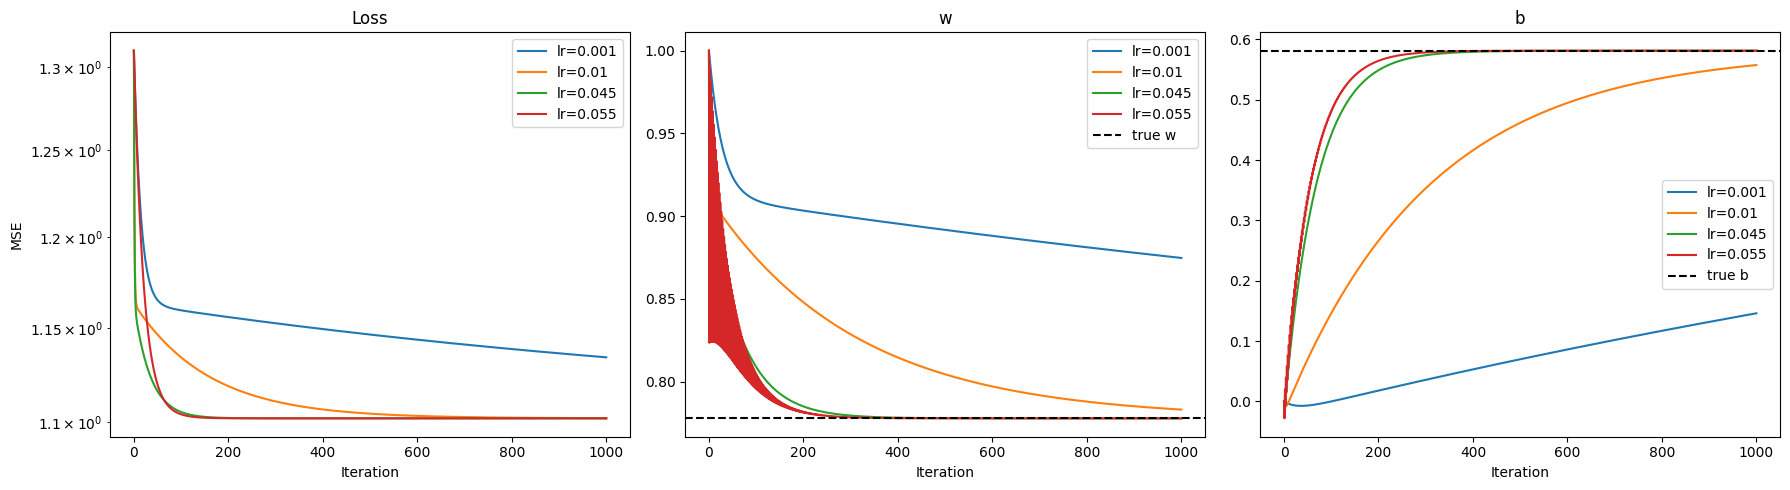


****************

lr: 0.056, w: 59.855886249004016, b: 13.736621733365682


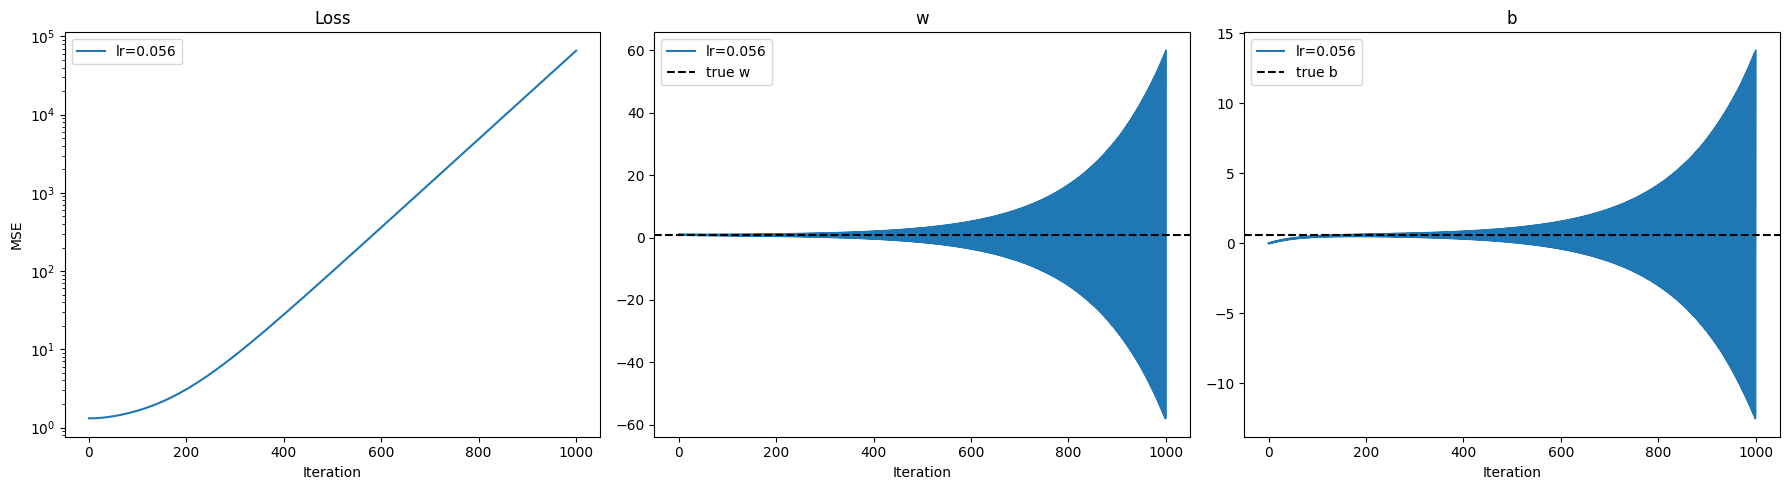

{0.056: (np.float64(59.855886249004016), np.float64(13.736621733365682))}

In [7]:
# Training the unscaled training set with different learning rates, and plotting.

plot_runs(x, y, [0.001, 0.01, 0.045, 0.055], 0.7778, 0.5813)

print("\n****************\n")

plot_runs(x, y, [0.056], 0.7778, 0.5813)


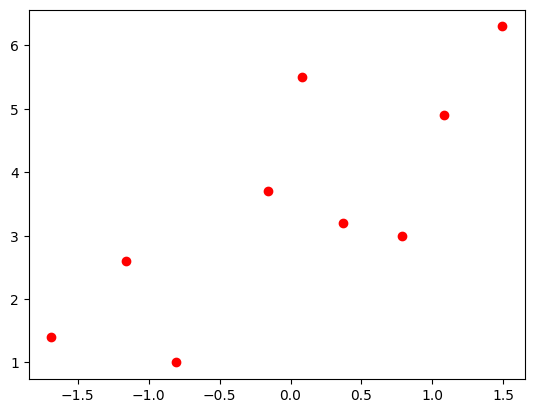

In [8]:
# Trying to fit a line with the scaled X values
# Now the center of the datas are in the y-axis (x=0).

x_mean = x.mean()
x_std = x.std()

x_scaled = (x - x_mean) / x_std

plt.scatter(x_scaled,y, color='red')
plt.show()

lr: 0.01, w: 1.3220406571061962, b: 3.511111105202026
lr: 0.1, w: 1.3220406576481802, b: 3.51111111111111
lr: 0.5, w: 1.3220406576481805, b: 3.511111111111111
lr: 0.9, w: 1.3220406576481805, b: 3.5111111111111106


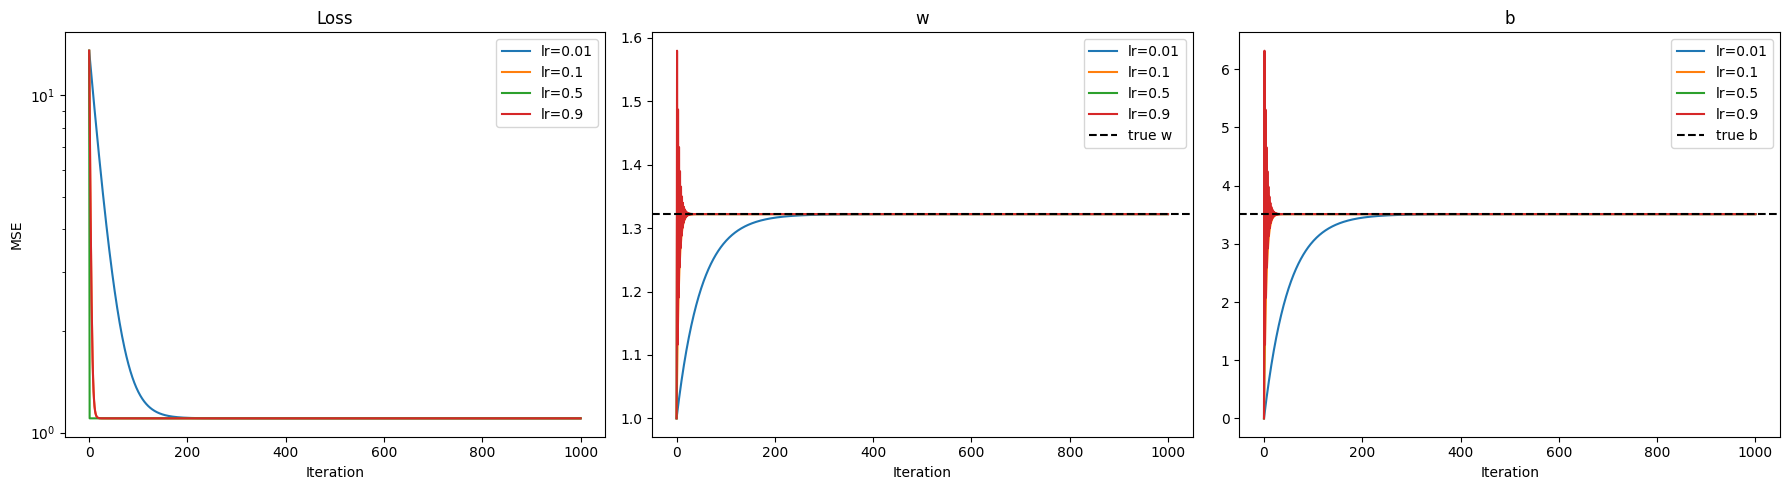

lr=0.01: scaled w=1.3220, b=3.5111 -> unscaled w=0.7778, b=0.5813
lr=0.1: scaled w=1.3220, b=3.5111 -> unscaled w=0.7778, b=0.5813
lr=0.5: scaled w=1.3220, b=3.5111 -> unscaled w=0.7778, b=0.5813
lr=0.9: scaled w=1.3220, b=3.5111 -> unscaled w=0.7778, b=0.5813


In [9]:
results = plot_runs(x_scaled, y, [0.01, 0.1, 0.5, 0.9], 1.322, 3.511)

# Unscaling
for lr, (w_s, b_s) in results.items():
    w_orig = w_s / x_std
    b_orig = b_s - w_s * x_mean / x_std
    print(f"lr={lr}: scaled w={w_s:.4f}, b={b_s:.4f} -> unscaled w={w_orig:.4f}, b={b_orig:.4f}")

lr: 1, w: 1.0, b: 0.0
lr: 1.1, w: -4.888287633675795e+78, b: -5.3295509797613504e+79


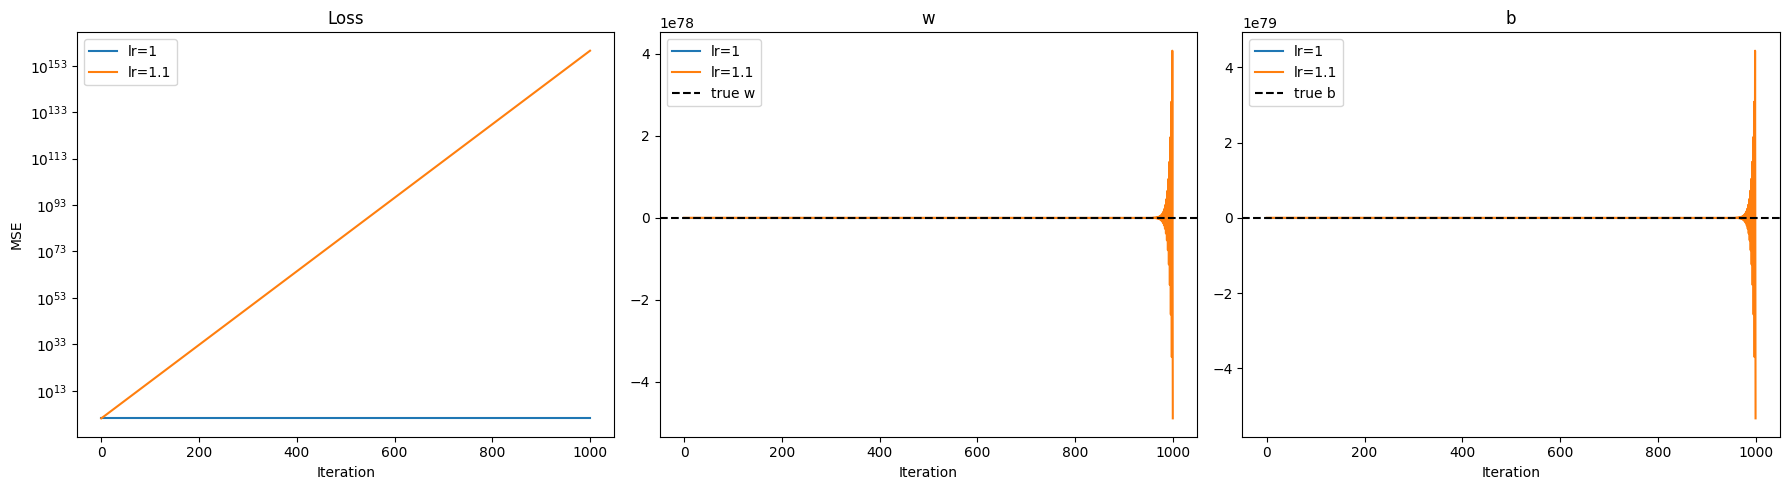

lr=1: scaled w=1.0000, b=0.0000 -> unscaled w=0.5883, b=-2.2161
lr=1.1: scaled w=-4888287633675794744819041024558024019947507564914556043528874870595269397839872.0000, b=-53295509797613503668371263703559357000569394966419233786860308340974878799691776.0000 -> unscaled w=-2876016234480827842914700447890697121008306503758340171739882182155925859598336.0000, b=-42462515314402387695202915711142605105271246775997255074856302940466872443731968.0000


In [11]:
# Trying training scaled x values with larger learning rates to test if it explodes

scaled_results = plot_runs(x_scaled, y, [1, 1.1], 1.322, 3.511)

# Unscaling
for lr, (w_s, b_s) in scaled_results.items():
    w_orig = w_s / x_std
    b_orig = b_s - w_s * x_mean / x_std
    print(f"lr={lr}: scaled w={w_s:.4f}, b={b_s:.4f} -> unscaled w={w_orig:.4f}, b={b_orig:.4f}")

## Results

**Unscaled x:** Gradient descent converges for learning rates up to 0.055 and diverges at 0.056. Small learning rates are very slow: with lr = 0.001, b only reaches 0.15 after 1000 iterations (the true value is 0.58). Near the limit (lr = 0.055), w oscillates around its optimum before settling. At 0.056 this oscillation grows every step instead of shrinking, and the parameters explode.

**Scaled x:** After standardizing x, the learning rate limit increases from about 0.056 to 1.0. With lr = 0.5 the model reaches the minimum in a single step. At lr = 0.9 it still converges, at lr = 1.0 it oscillates forever (after 1000 iterations it is back at its starting values), and at lr = 1.1 it diverges.

**Same model:** Converting the scaled parameters back gives w = 0.7778 and b = 0.5813, the same line found with the closed-form solution. Scaling does not change the model, only how fast and how reliably gradient descent reaches it.

## Why scaling helps

The gradients of the two parameters differ only by one factor:

- dJ/dw = -2/n · Σ xᵢ (yᵢ - ŷᵢ)
- dJ/db = -2/n · Σ 1 · (yᵢ - ŷᵢ)

The gradient of w is multiplied by x, the gradient of b by 1. With x between 0.9 and 6.3, w is much more sensitive than b. Since both use the same learning rate, the most sensitive parameter (w) limits how large it can be, and b has to move slowly with those small steps. In addition, because x is not centered at zero, changing w shifts all predictions up or down, so the best b keeps changing as w changes.

Standardizing x fixes both problems: centering removes the coupling between w and b, and dividing by the standard deviation makes their gradients similar in size, so one learning rate works for both.

This matters much more in real data. In the churn dataset, features like Balance (0 to 250,000) and NumOfProducts (1 to 4) differ by orders of magnitude, so gradient descent without scaling would be extremely slow or unstable. This is why models trained with gradient descent, such as logistic regression and neural networks, need scaled features, while tree-based models do not.